In [1]:
import numpy as np
from oneargopy.OneArgo import Argo
from argopy import DataFetcher as ArgoDataFetcher
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
import cmocean
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import matplotlib.cm as cm # new package for the colorbar
import matplotlib.patches as mpatches
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from matplotlib.ticker import LogLocator, FormatStrFormatter
from matplotlib.colors import LogNorm
import gsw

## Downloading new data - don't need to run when restarting kernel

In [2]:
argo = Argo('argo_config.json')

Starting initialize process...
Your current download settings are: 
[DownloadSettings] -> 
Base Directory: ., 
Subdirectories: ['Index', 'Meta', 'Tech', 'Traj', 'Profiles'], 
Index Files: ['ar_index_global_traj.txt', 'ar_index_global_tech.txt', 'ar_index_global_meta.txt', 'ar_index_global_prof.txt', 'argo_synthetic-profile_index.txt'], 
Verbose Setting: True, 
Max Attempts: 5, 
Keep Index In Memory: True, 
Float Type: bgc

Your current source settings are: 
[Source Settings] -> 
Hosts: ['https://data-argo.ifremer.fr/', 'https://usgodae.org/ftp/outgoing/argo/'], 
Available Variables: None, 
Data Assimilation Centers: None

Checking for subdirectories...
The Index directory already exists
The Meta directory already exists
The Tech directory already exists
The Traj directory already exists
The Profiles directory already exists

ar_index_global_traj.txt does not need to be updated yet.
ar_index_global_tech.txt does not need to be updated yet.
ar_index_global_meta.txt does not need to be up

In [4]:
pressure = argo.select_profiles(lon_lim=[150,180], lat_lim=[-68,-58], type = 'bgc', sensor = 'CHLA') # all bgc floats within region

Starting select_profiles...
Validating parameters...
Validating longitude and latitude limits...
Validating start and end dates...
Validating 'type' keyword argument...
Preparing float data for filtering...
Filtering through 20336 floats
There are 3340670 profiles associated with these floats

Sorting floats for those within the geographic range...
Creating point list from profiles...
Creating polygon...
79 floats fall within the geographic range
2602 profiles associated with those floats
Applying outside=None constraints...
79 floats selected
2602 profiles selected according to time and space constraints
Floats Selected: dict_keys([1901135, 1901153, 1901155, 1901157, 1902662, 2901936, 2903454, 3902129, 4903658, 5900345, 5901178, 5901645, 5901648, 5901698, 5901699, 5903242, 5903248, 5903260, 5903630, 5903717, 5903719, 5903720, 5903721, 5903722, 5903723, 5903939, 5904104, 5904105, 5904179, 5904481, 5904482, 5904483, 5904598, 5904599, 5904676, 5904677, 5904682, 5904688, 5905096, 5905097,

In [5]:
pdf = argo.load_float_data(pressure, variables=['DOXY','TEMP','PSAL','CHLA', 'BBP700','NITRATE','PH_IN_SITU_TOTAL']) 

Validating passed floats...
Validating passed 'variables'...
1901135_Sprof.nc does not need to be updated yet.
1901153_Sprof.nc does not need to be updated yet.
1901155_Sprof.nc does not need to be updated yet.
1901157_Sprof.nc does not need to be updated yet.
1902662_Sprof.nc does not need to be updated yet.
2901936_Sprof.nc does not need to be updated yet.
2903454_Sprof.nc does not need to be updated yet.
3902129_Sprof.nc does not need to be updated yet.
4903658_Sprof.nc does not need to be updated yet.
5900345_Sprof.nc does not need to be updated yet.
5901178_Sprof.nc does not need to be updated yet.
5901645_Sprof.nc does not need to be updated yet.
5901648_Sprof.nc does not need to be updated yet.
5901698_Sprof.nc does not need to be updated yet.
5901699_Sprof.nc does not need to be updated yet.
5903242_Sprof.nc does not need to be updated yet.
5903248_Sprof.nc does not need to be updated yet.
5903260_Sprof.nc does not need to be updated yet.
5903630_Sprof.nc does not need to be up

TypeError: unsupported type for timedelta days component: MaskedConstant

In [6]:
pdf.to_csv('/Users/lilah/Documents/IBIS_Project/Data_Summer/new_bgc_profiles_BR_extended_area_all_time.csv', index = 'False')

NameError: name 'pdf' is not defined

## Start here after importing when restarting kernel

In [2]:
df_new = pd.read_csv('/Users/lilah/Documents/IBIS_Project/Data_Summer/new_bgc_profiles_BR_extended_area_all_time.csv')
df_old = pd.read_csv('/Users/lilah/Documents/IBIS_Project/Data_School_Year/old_AAR_BGC_extended_region_alltime.csv')

/var/folders/sr/nn_fjjln6s33md98tyfc3rd40000gn/T/ipykernel_27851/498635473.py:2: DtypeWarning: Columns (0: LATITUDE, 1: LONGITUDE) have mixed types. Specify dtype option on import or set low_memory=False.
  df_old = pd.read_csv('/Users/lilah/Documents/IBIS_Project/Data_School_Year/old_AAR_BGC_extended_region_alltime.csv')


In [3]:
df_new

,Unnamed: 0.1,Unnamed: 0,WMOID,CYCLE_NUMBER,DIRECTION,DATE,DATE_QC,LATITUDE,LONGITUDE,POSITION_QC,...,NITRATE,NITRATE_QC,NITRATE_ADJUSTED,NITRATE_ADJUSTED_QC,NITRATE_ADJUSTED_ERROR,PH_IN_SITU_TOTAL,PH_IN_SITU_TOTAL_QC,PH_IN_SITU_TOTAL_ADJUSTED,PH_IN_SITU_TOTAL_ADJUSTED_QC,PH_IN_SITU_TOTAL_ADJUSTED_ERROR
0,0,0,3902129,41,A,2019-03-13 12:30:40.000000,1,-63.164055,163.932868,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1,3902129,41,A,2019-03-13 12:30:40.000000,1,-63.164055,163.932868,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,2,3902129,41,A,2019-03-13 12:30:40.000000,1,-63.164055,163.932868,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,3,3902129,41,A,2019-03-13 12:30:40.000000,1,-63.164055,163.932868,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,4,3902129,41,A,2019-03-13 12:30:40.000000,1,-63.164055,163.932868,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110235,110235,110235,6902891,75,A,2026-01-24 02:47:00,1,-62.792860,169.976922,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
110236,110236,110236,6902891,75,A,2026-01-24 02:47:00,1,-62.792860,169.976922,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
110237,110237,110237,6902891,75,A,2026-01-24 02:47:00,1,-62.792860,169.976922,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
110238,110238,110238,6902891,75,A,2026-01-24 02:47:00,1,-62.792860,169.976922,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df_old

,Unnamed: 0,WMOID,CYCLE_NUMBER,DIRECTION,DATE,DATE_QC,LATITUDE,LONGITUDE,POSITION_QC,PRES,...,NITRATE,NITRATE_QC,NITRATE_ADJUSTED,NITRATE_ADJUSTED_QC,NITRATE_ADJUSTED_ERROR,PH_IN_SITU_TOTAL,PH_IN_SITU_TOTAL_QC,PH_IN_SITU_TOTAL_ADJUSTED,PH_IN_SITU_TOTAL_ADJUSTED_QC,PH_IN_SITU_TOTAL_ADJUSTED_ERROR
0,0,1901135,174,A,2013-08-23 01:13:44.999978,1,-62.053,150.025,1,6.10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1901135,174,A,2013-08-23 01:13:44.999978,1,-62.053,150.025,1,10.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1901135,174,A,2013-08-23 01:13:44.999978,1,-62.053,150.025,1,14.80,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1901135,174,A,2013-08-23 01:13:44.999978,1,-62.053,150.025,1,19.70,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1901135,174,A,2013-08-23 01:13:44.999978,1,-62.053,150.025,1,24.90,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1519016,1519016,7902154,16,A,2025-10-16 06:34:24.000693,1,-58.1553,174.3372,1,1600.10,...,32.842896,3.0,33.114273,1.0,1.311489,7.856922,3.0,7.838748,1.0,0.014984
1519017,1519017,7902154,16,A,2025-10-16 06:34:24.000693,1,-58.1553,174.3372,1,1699.80,...,32.520950,3.0,32.792328,1.0,1.311867,7.858857,3.0,7.840679,1.0,0.014990
1519018,1519018,7902154,16,A,2025-10-16 06:34:24.000693,1,-58.1553,174.3372,1,1799.52,...,32.327694,3.0,32.599070,1.0,1.312243,7.861394,3.0,7.843212,1.0,0.014996
1519019,1519019,7902154,16,A,2025-10-16 06:34:24.000693,1,-58.1553,174.3372,1,1900.15,...,31.881544,3.0,32.152920,1.0,1.312737,7.864672,3.0,7.846485,1.0,0.015004


In [5]:
WMOIDS_new = df_new['WMOID'].unique().tolist()
WMOIDS_new

[3902129,
 5905375,
 5905379,
 5905555,
 5906581,
 5906582,
 5906583,
 6902885,
 6902891]

In [6]:
WMOIDS_old = df_old['WMOID'].unique().tolist()
WMOIDS_old

[1901135,
 1901153,
 1901155,
 1901157,
 1902662,
 2903454,
 3902129,
 5900345,
 5901178,
 5901645,
 5901648,
 5901698,
 5901699,
 5903242,
 5903248,
 5903260,
 5903630,
 5903717,
 5903719,
 5903720,
 5903721,
 5903722,
 5903723,
 5903939,
 5904104,
 5904105,
 5904179,
 5904481,
 5904482,
 5904483,
 5904598,
 5904599,
 5904676,
 5904677,
 5904682,
 5904688,
 5905096,
 5905097,
 5905098,
 5905099,
 5905100,
 5905101,
 5905102,
 5905103,
 5905232,
 5905372,
 5905373,
 5905374,
 5905375,
 5905376,
 5905377,
 5905379,
 5905396,
 5905555,
 5905556,
 5905557,
 5905638,
 5906207,
 5906221,
 5906442,
 5906509,
 5906581,
 5906582,
 5906583,
 5906624,
 6901004,
 6902814,
 6902885,
 6902891,
 6903190,
 6903233,
 6903768,
 6990587,
 7902154]

## Chlorophyll comparison new and old data

## WMOID 5905555

In [7]:
comp_new = df_new.loc[df_new['WMOID'] == 5905555]
comp_old = df_old.loc[df_old['WMOID'] == 5905555]
# comp_new
# comp_old

In [10]:
new1 = comp_new.loc[comp_new['CYCLE_NUMBER'] == 55]
old1 = comp_old.loc[comp_old['CYCLE_NUMBER'] == 55]

new2 = comp_new.loc[comp_new['CYCLE_NUMBER'] == 57]
old2 = comp_old.loc[comp_old['CYCLE_NUMBER'] == 57]

new3 = comp_new.loc[comp_new['CYCLE_NUMBER'] == 60]
old3 = comp_old.loc[comp_old['CYCLE_NUMBER'] == 60]

new4 = comp_new.loc[comp_new['CYCLE_NUMBER'] == 63]
old4 = comp_old.loc[comp_old['CYCLE_NUMBER'] == 63]

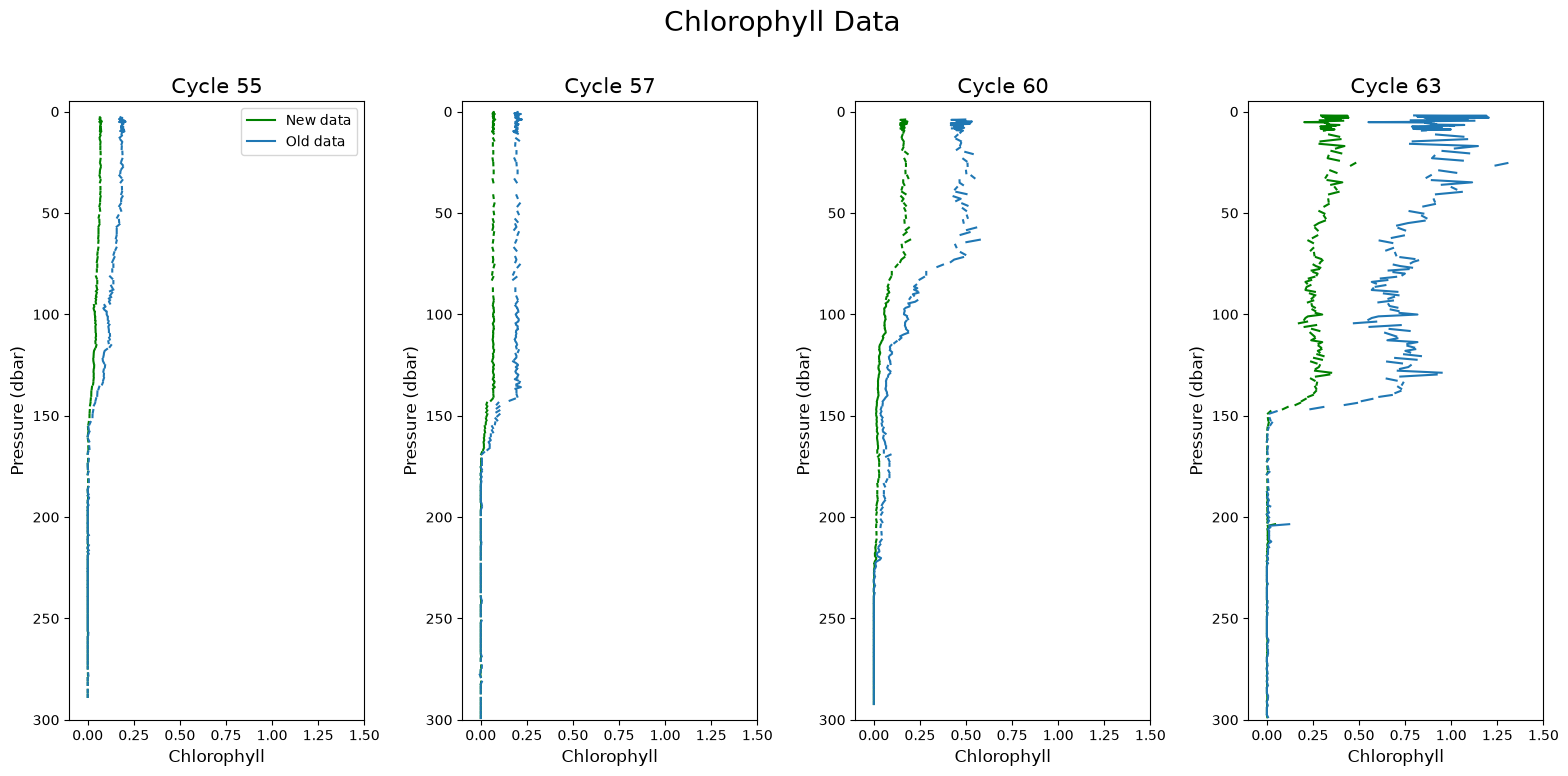

In [11]:
fig = plt.figure(figsize=(16, 8))
ax = fig.add_subplot(141)
ax.plot(new1['CHLA_ADJUSTED'], new1['PRES_ADJUSTED'], c ='g', label ='New data')
ax.plot(old1['CHLA_ADJUSTED'], old1['PRES_ADJUSTED'], label='Old data')
ax.invert_yaxis()
ax.set_xlim(-0.1, 1.5)
ax.set_ylim(300, -5)
ax.set_xlabel('Chlorophyll', fontsize =12)
ax.set_ylabel('Pressure (dbar)', fontsize =12)
ax.set_title('Cycle 55',  fontsize =15)
ax.legend()

ax = fig.add_subplot(142)
ax.plot(new2['CHLA_ADJUSTED'], new2['PRES_ADJUSTED'], c ='g', label ='New data')
ax.plot(old2['CHLA_ADJUSTED'], old2['PRES_ADJUSTED'], label='Old data')
ax.invert_yaxis()
ax.set_xlim(-0.1, 1.5)
ax.set_ylim(300, -5)
ax.set_xlabel('Chlorophyll', fontsize =12)
ax.set_ylabel('Pressure (dbar)', fontsize =12)
ax.set_title('Cycle 57',  fontsize =15)

ax = fig.add_subplot(143)
ax.plot(new3['CHLA_ADJUSTED'], new3['PRES_ADJUSTED'], c ='g', label ='New data')
ax.plot(old3['CHLA_ADJUSTED'], old3['PRES_ADJUSTED'], label='Old data')
ax.invert_yaxis()
ax.set_xlim(-0.1, 1.5)
ax.set_ylim(300, -5)
ax.set_xlabel('Chlorophyll', fontsize =12)
ax.set_ylabel('Pressure (dbar)', fontsize =12)
ax.set_title('Cycle 60',  fontsize =15)

ax = fig.add_subplot(144)
ax.plot(new4['CHLA_ADJUSTED'], new4['PRES_ADJUSTED'], c ='g', label ='New data')
ax.plot(old4['CHLA_ADJUSTED'], old4['PRES_ADJUSTED'], label='Old data')
ax.invert_yaxis()
ax.set_xlim(-0.1, 1.5)
ax.set_ylim(300, -5)
ax.set_xlabel('Chlorophyll', fontsize =12)
ax.set_ylabel('Pressure (dbar)', fontsize =12)
ax.set_title('Cycle 63', fontsize =15)

fig.suptitle('Chlorophyll Data', fontsize = 20)
plt.tight_layout(pad=2)


## WMOID 6902891

In [12]:
comp_new = df_new.loc[df_new['WMOID'] == 5906581]
comp_old = df_old.loc[df_old['WMOID'] == 5906581]
# comp_new
# comp_old

In [13]:
comp_new['CHLA_ADJUSTED']

27228         NaN
27229         NaN
27230    0.182555
27231         NaN
27232         NaN
           ...   
32238    0.000000
32239    0.000000
32240    0.000000
32241    0.001326
32242    0.000000
Name: CHLA_ADJUSTED, Length: 5015, dtype: float64

In [14]:
comp_old['CHLA_ADJUSTED']

1042353        NaN
1042354        NaN
1042355        NaN
1042356    0.85045
1042357        NaN
            ...   
1079417    0.00365
1079418    0.00365
1079419    0.00365
1079420    0.00730
1079421    0.00365
Name: CHLA_ADJUSTED, Length: 37069, dtype: float64

In [15]:
comp_new['CYCLE_NUMBER']

27228     4
27229     4
27230     4
27231     4
27232     4
         ..
32238    12
32239    12
32240    12
32241    12
32242    12
Name: CYCLE_NUMBER, Length: 5015, dtype: int64

In [16]:
comp_old['CYCLE_NUMBER']

1042353     1
1042354     1
1042355     1
1042356     1
1042357     1
           ..
1079417    86
1079418    86
1079419    86
1079420    86
1079421    86
Name: CYCLE_NUMBER, Length: 37069, dtype: int64

In [17]:
new1['CHLA_ADJUSTED']

21118    NaN
21119    NaN
21120    NaN
21121    NaN
21122    NaN
        ... 
21770    NaN
21771    0.0
21772    0.0
21773    NaN
21774    0.0
Name: CHLA_ADJUSTED, Length: 657, dtype: float64

In [20]:
new1 = comp_new.loc[comp_new['CYCLE_NUMBER'] == 4]
old1 = comp_old.loc[comp_old['CYCLE_NUMBER'] == 4]

new2 = comp_new.loc[comp_new['CYCLE_NUMBER'] == 12]
old2 = comp_old.loc[comp_old['CYCLE_NUMBER'] == 12]

new3 = comp_new.loc[comp_new['CYCLE_NUMBER'] == 33]
old3 = comp_old.loc[comp_old['CYCLE_NUMBER'] == 33]

new4 = comp_new.loc[comp_new['CYCLE_NUMBER'] == 42]
old4 = comp_old.loc[comp_old['CYCLE_NUMBER'] == 42]

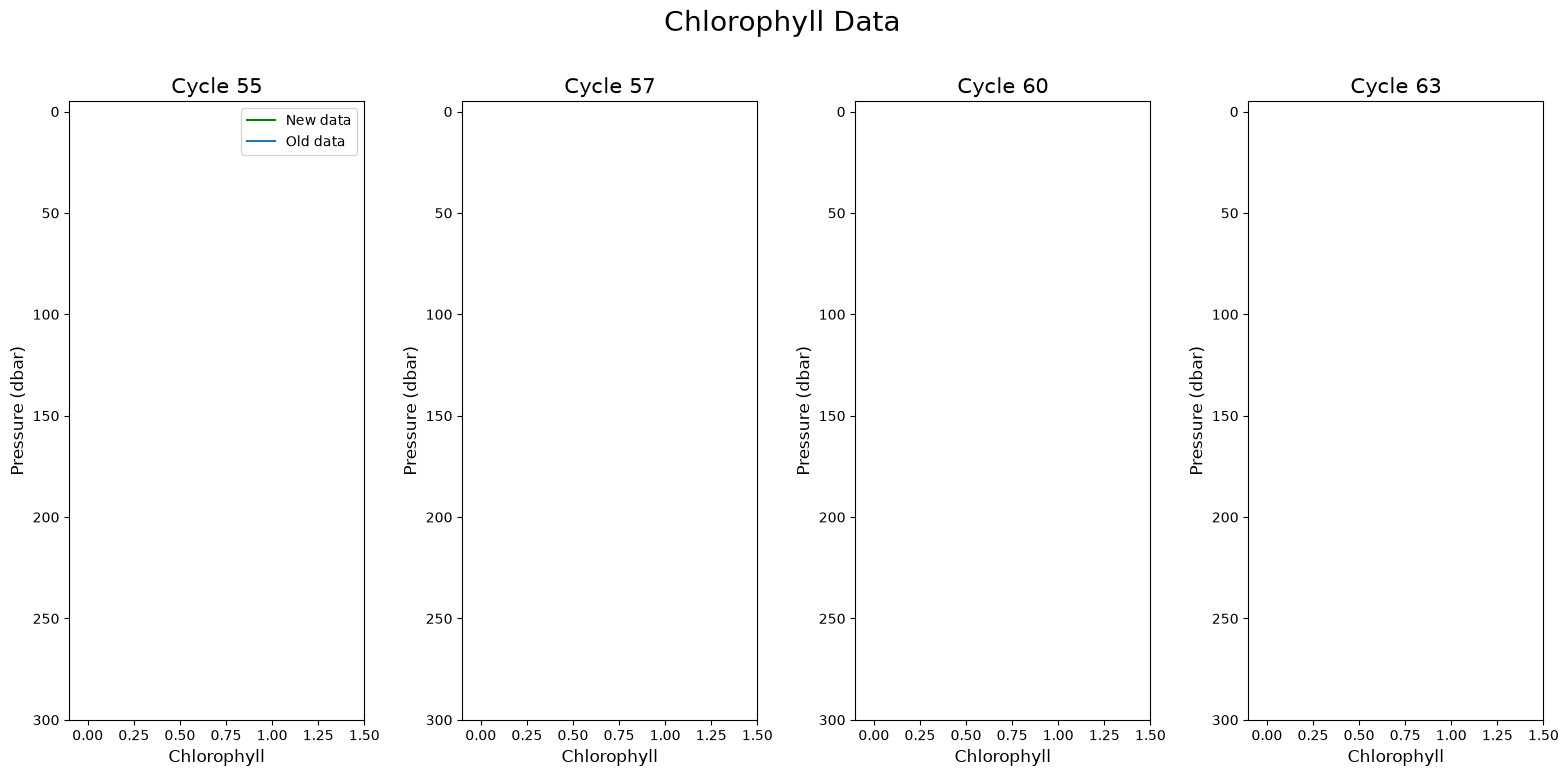

In [21]:
fig = plt.figure(figsize=(16, 8))
ax = fig.add_subplot(141)
ax.plot(new1['CHLA_ADJUSTED'], new1['PRES_ADJUSTED'], c ='g', label ='New data')
ax.plot(old1['CHLA_ADJUSTED'], old1['PRES_ADJUSTED'], label='Old data')
ax.invert_yaxis()
ax.set_xlim(-0.1, 1.5)
ax.set_ylim(300, -5)
ax.set_xlabel('Chlorophyll', fontsize =12)
ax.set_ylabel('Pressure (dbar)', fontsize =12)
ax.set_title('Cycle 55',  fontsize =15)
ax.legend()

ax = fig.add_subplot(142)
ax.plot(new2['CHLA_ADJUSTED'], new2['PRES_ADJUSTED'], c ='g', label ='New data')
ax.plot(old2['CHLA_ADJUSTED'], old2['PRES_ADJUSTED'], label='Old data')
ax.invert_yaxis()
ax.set_xlim(-0.1, 1.5)
ax.set_ylim(300, -5)
ax.set_xlabel('Chlorophyll', fontsize =12)
ax.set_ylabel('Pressure (dbar)', fontsize =12)
ax.set_title('Cycle 57',  fontsize =15)

ax = fig.add_subplot(143)
ax.plot(new3['CHLA_ADJUSTED'], new3['PRES_ADJUSTED'], c ='g', label ='New data')
ax.plot(old3['CHLA_ADJUSTED'], old3['PRES_ADJUSTED'], label='Old data')
ax.invert_yaxis()
ax.set_xlim(-0.1, 1.5)
ax.set_ylim(300, -5)
ax.set_xlabel('Chlorophyll', fontsize =12)
ax.set_ylabel('Pressure (dbar)', fontsize =12)
ax.set_title('Cycle 60',  fontsize =15)

ax = fig.add_subplot(144)
ax.plot(new4['CHLA_ADJUSTED'], new4['PRES_ADJUSTED'], c ='g', label ='New data')
ax.plot(old4['CHLA_ADJUSTED'], old4['PRES_ADJUSTED'], label='Old data')
ax.invert_yaxis()
ax.set_xlim(-0.1, 1.5)
ax.set_ylim(300, -5)
ax.set_xlabel('Chlorophyll', fontsize =12)
ax.set_ylabel('Pressure (dbar)', fontsize =12)
ax.set_title('Cycle 63', fontsize =15)

fig.suptitle('Chlorophyll Data', fontsize = 20)
plt.tight_layout(pad=2)


## Using old code, datetime and season without season - didn't work

In [156]:
df_new['DATE']

0         2019-03-13 12:30:40.000000
1         2019-03-13 12:30:40.000000
2         2019-03-13 12:30:40.000000
3         2019-03-13 12:30:40.000000
4         2019-03-13 12:30:40.000000
                     ...            
110235           2026-01-24 02:47:00
110236           2026-01-24 02:47:00
110237           2026-01-24 02:47:00
110238           2026-01-24 02:47:00
110239           2026-01-24 02:47:00
Name: DATE, Length: 110240, dtype: str

In [157]:
#convert to datetime
df_new['DATE'] = pd.to_datetime(df_new['DATE'],format = 'mixed')
#add year and month columns
df_new["year"] = df_new["DATE"].dt.year
df_new["month"] = df_new["DATE"].dt.month

# Define a season label: if month >=10 then season = year-year+1, else if month <=3 then season = (year-1)-year
def assign_season(row):
    m = row["month"]
    y = row["year"]
    if m >= 8:         # Aug, Sept, Oct, Nov, Dec
        return f"{y}-{y+1}"
    elif m <= 4:        # Jan, Feb, Mar
        return f"{y-1}-{y}"
    else:
        return f"{y}"   # outside the austral productive season (Apr-Sep)

#subset data with good QC only
qc_flags = [1,2,8]
df_new_season = df_new[df_new['CHLA_ADJUSTED_QC'].isin(qc_flags) & df_new['BBP700_ADJUSTED_QC'].isin(qc_flags) & df_new['DOXY_ADJUSTED_QC'].isin(qc_flags) & df_new['PSAL_ADJUSTED_QC'].isin(qc_flags)]

df_new_season["season"] = df_new.apply(assign_season, axis=1)

df_new_season['DATE']

1591    2020-01-05 17:06:37.001832
1594    2020-01-05 17:06:37.001832
1598    2020-01-05 17:06:37.001832
1601    2020-01-05 17:06:37.001832
1605    2020-01-05 17:06:37.001832
                   ...            
55629   2024-03-12 21:54:10.002331
55630   2024-03-12 21:54:10.002331
55631   2024-03-12 21:54:10.002331
55632   2024-03-12 21:54:10.002331
55633   2024-03-12 21:54:10.002331
Name: DATE, Length: 8166, dtype: datetime64[us]

In [158]:
def subset_yr(df, yr1,yr2):
    
    subset = df[df['year'].isin([yr1,yr2])]
    # add subset by the productive months
    # subset = subset[subset['month'].isin([1,2,3,4,8,9, 10,11,12])]
    
    return subset

df_new_yr = subset_yr(df_new_season,2014,2015)
df_new_yr

,Unnamed: 0.1,Unnamed: 0,WMOID,CYCLE_NUMBER,DIRECTION,DATE,DATE_QC,LATITUDE,LONGITUDE,POSITION_QC,...,NITRATE_ADJUSTED_QC,NITRATE_ADJUSTED_ERROR,PH_IN_SITU_TOTAL,PH_IN_SITU_TOTAL_QC,PH_IN_SITU_TOTAL_ADJUSTED,PH_IN_SITU_TOTAL_ADJUSTED_QC,PH_IN_SITU_TOTAL_ADJUSTED_ERROR,year,month,season


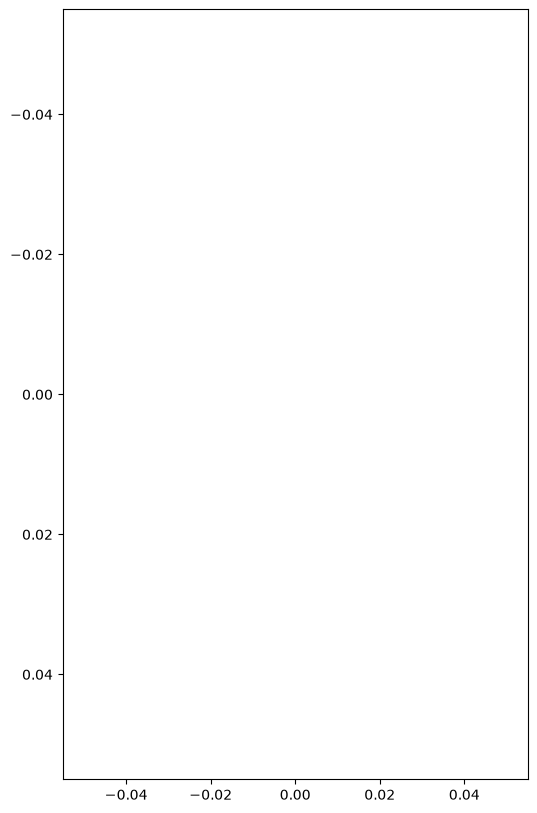

In [159]:
def chla_comp(df, WMOID, cycle):

    df = df[df['WMOID'].isin([WMOID])]
    df = df[df['CYCLE_NUMBER'].isin([cycle])]

    df['DATE'] = pd.to_datetime(df['DATE'])
    date_nums = mdates.date2num(df['DATE'])

    fig = plt.figure(figsize=(6, 10))

    ax = fig.add_subplot(111)
    ax.plot(df.loc[df['CYCLE_NUMBER'] == 41, 'CHLA_ADJUSTED'], df.loc[df['CYCLE_NUMBER'] == 41, 'PRES_ADJUSTED'])
    ax.invert_yaxis()

    plt.show()

chla_comp(df=df_new, WMOID=3902129, cycle=41)
